<a href="https://colab.research.google.com/github/Zong0120/Where_is_Waldo/blob/YOLOv8/Yolov8_model_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
try:
  import ultralytics
  print("Ultralytics 已安裝，版本:", ultralytics.__version__)
except ImportError:
  print("Ultralytics 未安裝，正在安裝...")
  !pip install ultralytics
import torch
import cv2
import matplotlib.pyplot as plt
import os
import shutil
import gdown
from ultralytics import YOLO
from math import ceil
import requests
from PIL import Image
from PIL import ImageDraw
import re

Ultralytics 未安裝，正在安裝...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 976.9/976.9 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu

In [2]:
#在Colab建立資料夾
colab_save_path = "/content"

folder_name = "Where is Waldo.v3i.yolov8"
folder_name_split = "Where is Waldo.v3i.yolov8_split"

folder_list = ["train", "valid", "test"]
folder_list_2 = ["images", "labels"]

for folder in folder_list:
  for folder_2 in folder_list_2:
    folder_path = os.path.join(colab_save_path, folder_name_split, folder, folder_2)
    if not os.path.exists(folder_path):
      os.makedirs(folder_path)
      print(f"建立資料夾: {folder_path}")

建立資料夾: /content/Where is Waldo.v3i.yolov8_split/train/images
建立資料夾: /content/Where is Waldo.v3i.yolov8_split/train/labels
建立資料夾: /content/Where is Waldo.v3i.yolov8_split/valid/images
建立資料夾: /content/Where is Waldo.v3i.yolov8_split/valid/labels
建立資料夾: /content/Where is Waldo.v3i.yolov8_split/test/images
建立資料夾: /content/Where is Waldo.v3i.yolov8_split/test/labels


In [3]:
#讀取檔案並解壓縮
zip_url = "https://raw.githubusercontent.com/Zong0120/Where_is_Waldo/main/Where%20is%20Waldo.v3i.yolov8.zip"
zip_name = "Where is Waldo.v3i.yolov8.zip"

response = requests.get(zip_url, stream=True)  #以串流方式下載
with open(zip_name, "wb") as file:
    for chunk in response.iter_content(chunk_size=8192):  #以8KB為單位寫入檔案
        file.write(chunk)
print(f"下載成功：{zip_name}")

#解壓縮
shutil.unpack_archive(zip_name, folder_name)
print(f"解壓縮完成：{folder_name}")

下載成功：Where is Waldo.v3i.yolov8.zip
解壓縮完成：Where is Waldo.v3i.yolov8


In [4]:
model_path = "https://drive.google.com/file/d/1E82aYA7yU0DRhNo-Qgf4rP-CFaA4u4he/view?usp=drive_link"  # 替換成你的模型 path
output_path = "best.pt"  # 下載後儲存的檔名
gdown.download(model_path, output=output_path, fuzzy=True)
try:
  model = YOLO("/content/best.pt")
except ImportError:
  print("error")

Downloading...
From: https://drive.google.com/uc?id=1E82aYA7yU0DRhNo-Qgf4rP-CFaA4u4he
To: /content/best.pt
100%|██████████| 6.25M/6.25M [00:00<00:00, 13.4MB/s]


In [5]:
#取得資料夾所有符合附檔名的檔案
def get_files_path(folder_path, file_extension):

  all_files = os.listdir(folder_path)

  files = [f for f in all_files if any(f.endswith(ext) for ext in file_extension)]

  files_path = [os.path.join(folder_path, single_file) for single_file in files]

  return files_path

In [6]:
#修改檔名
def extract_number(file_path):
  file_name = os.path.basename(file_path)
  #抓出開頭的數字
  match = re.match(r"(\d+)_jpg", file_name)
  if match:
    return int(match.group(1))
  else:
    return float("inf")

for i in range(len(folder_list)):
  for j in range(len(folder_list_2)):
    folder_path = os.path.join(colab_save_path, folder_name, folder_list[i], folder_list_2[j])

    ext = ".jpg" if folder_list_2[j] == "images" else ".txt"
    all_file_paths = get_files_path(folder_path, ext)

    for file_path in all_file_paths:
      num = extract_number(file_path)

      if num < 10:
        new_name = f"{num:02d}{ext}"
      else:
        new_name = f"{num}{ext}"

      old_path = file_path
      new_path = os.path.join(folder_path, new_name)
      os.rename(old_path, new_path)

print("檔名修改成功")

檔名修改成功


In [7]:
#分割圖片
def generate_image_block(image, labels, block_size, overlap_ratio):

  width, height = image.size
  stride = int(block_size[0] * (1 - overlap_ratio))
  num_row = ceil((height - block_size[1]) / stride) + 1
  num_col = ceil((width - block_size[0]) / stride) + 1

  label_list = []

  for label_str in labels:
    label = label_str.split(" ")

    #還原bounding box在原圖的座標
    label_id = int(label[0])
    label_xy = (float(label[1]) * width, float(label[2]) * height)
    label_wh = (float(label[3]) * width, float(label[4]) * height)

    label_list.append((label_id, label_xy, label_wh))

  for i in range(num_row):
    block_y1 = i * stride

    #最後一列
    if block_y1 + block_size[1] > height:
      block_y1 = height - block_size[1]

    for j in range(num_col):
      block_x1 = j * stride

      #最後一行
      if block_x1 + block_size[0] > width:
        block_x1 = width - block_size[0]

      block_x2 = block_x1 + block_size[0]
      block_y2 = block_y1 + block_size[1]

      block = image.crop((block_x1, block_y1, block_x2, block_y2))

      label_text = ""

      #調整label
      for label_id, label_xy, label_wh in label_list:

        block_xy = (block_x1, block_y1)
        block_wh = (block_size[0], block_size[1])

        label_final = get_label_in_block(block_xy, block_wh, label_xy, label_wh, label_id, 0.2)
        # print(f"區塊 ({i}, {j}) 的標籤: {label_final}")
        if len(label_final) > 0:
          label_text += label_final + "\n"
      #儲存到Colab
      file_name = f"{img_name}_{i:02}_{j:02}"
      image_path = os.path.join(colab_save_path, folder_name_split, set_name, "images", f"{file_name}.jpg")
      label_path = os.path.join(colab_save_path, folder_name_split, set_name, "labels", f"{file_name}.txt")

      block.save(image_path)

      with open(label_path, "w") as f:
        f.write(label_text)

In [8]:
#轉換bounding box座標(原圖到區塊)
def get_label_in_block(block_xy, block_wh, label_xy, label_wh, label_id, min_visible_ratio):

  block_x , block_y = block_xy  #區塊在原圖的座標
  block_w , block_h = block_wh  #區塊寬高
  label_x , label_y = label_xy  #bounding box的中心在原圖的座標
  label_w , label_h = label_wh  #bounding box的寬高

  #左上角和右下角
  x1 = label_x - label_w / 2
  y1 = label_y - label_h / 2
  x2 = label_x + label_w / 2
  y2 = label_y + label_h / 2

  #bounding box在區塊內的座標(不超出區塊邊界)
  clipped_x1 = max(x1, block_x)
  clipped_y1 = max(y1, block_y)
  clipped_x2 = min(x2, block_x + block_w)
  clipped_y2 = min(y2, block_y + block_h)

  #bounding box面積和分割後的面積
  area = label_w * label_h
  clipped_w = max(0, clipped_x2 - clipped_x1)
  clipped_h = max(0, clipped_y2 - clipped_y1)
  clipped_area = clipped_w * clipped_h

  #原圖不存在威利，label為空

  #bounding box在區塊邊界上
  if clipped_area == 0:
    return ""

  #比例達到標準，保留bounding box
  visible_ratio = clipped_area / area

  if visible_ratio < min_visible_ratio:
    return ""

  #新bounding box的中心點(平移到原圖的左上角區塊)
  new_label_x = (clipped_x1 + clipped_x2) / 2 - block_x
  new_label_y = (clipped_y1 + clipped_y2) / 2 - block_y

  #縮放到區塊大小，介於0-1
  norm_new_label_x = round(new_label_x / block_w, 6)
  norm_new_label_y = round(new_label_y / block_h, 6)
  norm_clipped_w = round(clipped_w / block_w, 6)
  norm_clipped_h = round(clipped_h / block_h, 6)

  label_str = f"{label_id} {norm_new_label_x} {norm_new_label_y} {norm_clipped_w} {norm_clipped_h}"

  return label_str

In [9]:
#圖片前處理
block_size = (640, 640)
overlap_ratio = 0.75

for i in range(len(folder_list)):
  print(f"處理資料夾: {folder_list[i]}")
  image_folder_path = os.path.join(colab_save_path, folder_name, folder_list[i], folder_list_2[0])
  label_folder_path = os.path.join(colab_save_path, folder_name, folder_list[i], folder_list_2[1])
  set_name = folder_list[i]
  image_paths = get_files_path(image_folder_path, ".jpg")

  for img_path in image_paths:
    #打開圖片
    image = Image.open(img_path)
    img_name = os.path.basename(img_path)
    img_name = os.path.splitext(img_name)[0]

    #打開label
    label_path = os.path.join(label_folder_path, f"{img_name}.txt")

    #轉換成label list(去掉頭尾的空白和換行字元)
    with open(label_path, "r") as f:
      labels = [line.strip() for line in f]

    #分割原圖
    generate_image_block(image, labels, block_size, overlap_ratio)
    print(f"{img_name} 分割完成")

處理資料夾: train
01 分割完成
17 分割完成
03 分割完成
09 分割完成
02 分割完成
19 分割完成
05 分割完成
13 分割完成
06 分割完成
04 分割完成
18 分割完成
11 分割完成
15 分割完成
16 分割完成
10 分割完成
處理資料夾: valid
07 分割完成
08 分割完成
處理資料夾: test
12 分割完成
14 分割完成


In [10]:
#預測模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

source_path = os.path.join(colab_save_path, folder_name_split, "test", "images")
result_path = os.path.join(colab_save_path, "runs", "detect", "predict")
result_test = model.predict(source_path, conf=0.7, save=True, save_txt=True, save_conf=True, device=device)


image 1/136 /content/Where is Waldo.v3i.yolov8_split/test/images/12_00_00.jpg: 640x640 (no detections), 8.7ms
image 2/136 /content/Where is Waldo.v3i.yolov8_split/test/images/12_00_01.jpg: 640x640 (no detections), 9.7ms
image 3/136 /content/Where is Waldo.v3i.yolov8_split/test/images/12_00_02.jpg: 640x640 1 Waldo, 16.1ms
image 4/136 /content/Where is Waldo.v3i.yolov8_split/test/images/12_00_03.jpg: 640x640 1 Waldo, 11.9ms
image 5/136 /content/Where is Waldo.v3i.yolov8_split/test/images/12_00_04.jpg: 640x640 1 Waldo, 11.2ms
image 6/136 /content/Where is Waldo.v3i.yolov8_split/test/images/12_01_00.jpg: 640x640 (no detections), 11.0ms
image 7/136 /content/Where is Waldo.v3i.yolov8_split/test/images/12_01_01.jpg: 640x640 (no detections), 8.1ms
image 8/136 /content/Where is Waldo.v3i.yolov8_split/test/images/12_01_02.jpg: 640x640 1 Waldo, 7.9ms
image 9/136 /content/Where is Waldo.v3i.yolov8_split/test/images/12_01_03.jpg: 640x640 1 Waldo, 8.8ms
image 10/136 /content/Where is Waldo.v3i.yolo

In [11]:
def convert_label_to_location(txt_path, block_size):

  with open(txt_path, "r") as f:
    labels = [line.strip() for line in f]

  label_list = []

  for label_str in labels:
    label = label_str.split(" ")

    #還原座標
    label_id = int(label[0])
    label_xy = (int(float(label[1]) * block_size), int(float(label[2]) * block_size))
    label_wh = (int(float(label[3]) * block_size), int(float(label[4]) * block_size))
    label_confidence = float(label[5])

    label_list.append((label_id, label_xy, label_wh, label_confidence))

  return label_list

def compute_iou(box1, box2):

  cx1, cy1, w1, h1 = box1
  cx2, cy2, w2, h2 = box2

  #轉換為(x_min, y_min, x_max, y_max)
  x1_min, y1_min = cx1 - w1 / 2, cy1 - h1 / 2
  x1_max, y1_max = cx1 + w1 / 2, cy1 + h1 / 2

  x2_min, y2_min = cx2 - w2 / 2, cy2 - h2 / 2
  x2_max, y2_max = cx2 + w2 / 2, cy2 + h2 / 2

  #交集
  inter_x_min = max(x1_min, x2_min)
  inter_y_min = max(y1_min, y2_min)
  inter_x_max = min(x1_max, x2_max)
  inter_y_max = min(y1_max, y2_max)

  inter_width = max(0, inter_x_max - inter_x_min)
  inter_height = max(0, inter_y_max - inter_y_min)
  intersection_area = inter_width * inter_height

  #聯集
  area1 = w1 * h1
  area2 = w2 * h2
  union_area = area1 + area2 - intersection_area

  iou = intersection_area / union_area if union_area > 0 else 0.0

  return iou

#刪除重疊的預測框
def non_maximum_suppression(boxes, iou_threshold=0.5):

  #根據類別分組，避免不同類別互相影響
  grouped_boxes = {}
  for box in boxes:
    class_id = box[0]
    if class_id not in grouped_boxes:
      grouped_boxes[class_id] = []
    grouped_boxes[class_id].append(box)

  #存放最終的NMS結果
  final_boxes = []

  for class_id, class_boxes in grouped_boxes.items():
    #信心度從高排到低
    class_boxes.sort(key=lambda b: b[5], reverse=True)

    #篩選過的預測框
    selected_boxes = []

    while class_boxes:
      #取出信心度最高的框
      best_box = class_boxes.pop(0)
      selected_boxes.append(best_box)

      #過濾IoU過高的框
      class_boxes = [
        box for box in class_boxes
        if compute_iou(best_box[1:5], box[1:5]) < iou_threshold
      ]

    #加入結果
    final_boxes.extend(selected_boxes)

  return final_boxes

已儲存預測結果 12 到 /content/output/12_out.jpg
已儲存預測結果 14 到 /content/output/14_out.jpg


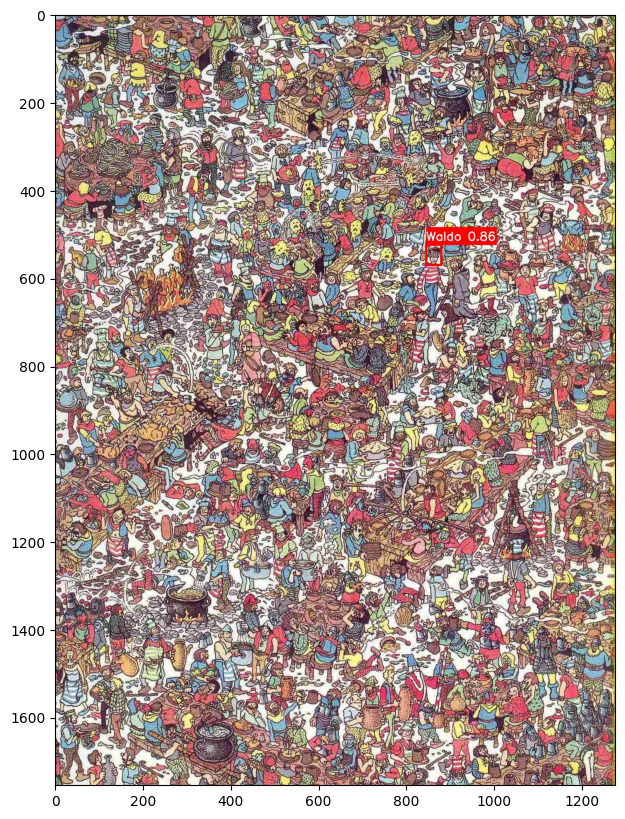

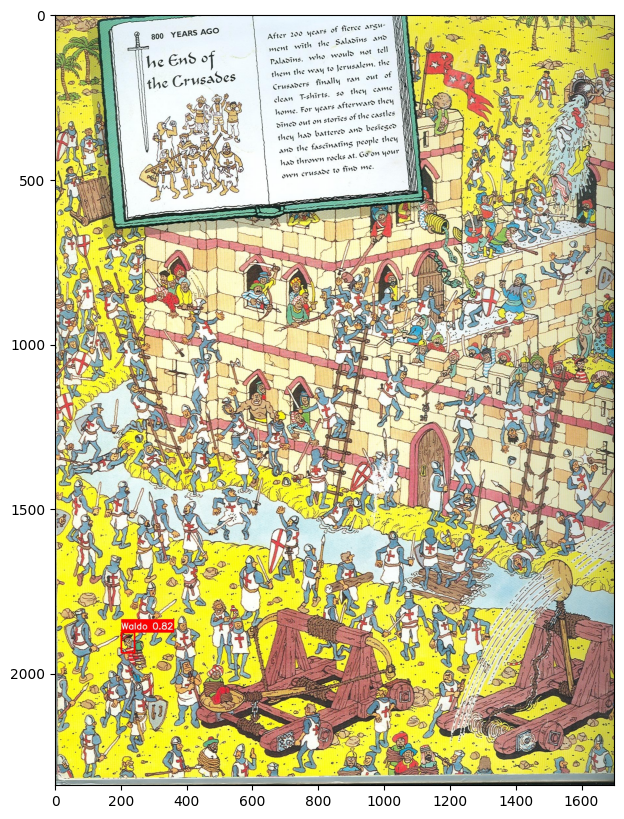

In [12]:
#顯示預測結果
import cv2
def process_images(image_folder, txt_folder, output_folder, block_size, stride):

    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    #取得原圖路徑、txt路徑
    image_paths = get_files_path(image_folder, ".jpg")
    txt_paths = get_files_path(txt_folder, ".txt")

    #建立txt檔案的字典
    txt_dict = {}
    for txt_path in txt_paths:
      txt_name = os.path.basename(txt_path)
      base_name = txt_name.split('_')[0]
      if base_name not in txt_dict:
        txt_dict[base_name] = []
      txt_dict[base_name].append(txt_path)
    #儲存原圖上的預測框
    all_boxes = {}

    for image_path in image_paths:
      image = cv2.imread(image_path)
      img_height, img_width = image.shape[:2]
      #原圖的檔名
      base_name = image_path.split("/")[-1].split(".")[0]
      #如果沒有對應的txt檔則跳過
      if base_name not in txt_dict:
        print(f"{base_name}.jpg 沒有txt檔案")
        continue

      for txt_path in txt_dict[base_name]:
        txt_name = os.path.basename(txt_path)
        parts = os.path.splitext(txt_name)[0].split('_')
        #print(f"txtName:{txt_name} parts:{parts}")
        if len(parts) < 3:
          print(f"{txt_name}.txt 檔名格式錯誤")

        try:
          row_index, col_index = int(parts[1].lstrip("0") or "0"), int(parts[2].lstrip("0") or "0")
        except ValueError:
          print(f"{txt_name}.txt 無法拆出row_index和col_index")
          continue

        #區塊在原圖的座標
        if row_index * stride + block_size > img_height:
          block_y = img_height - block_size
        else:
          block_y = row_index * stride

        if col_index * stride + block_size > img_width:
          block_x = img_width - block_size
        else:
          block_x = col_index * stride

        boxes = convert_label_to_location(txt_path, block_size)

        for id, (x, y), (w, h), conf in boxes:
          #預測框在原圖的座標
          orig_x, orig_y = block_x + x, block_y + y

          if base_name not in all_boxes:
              all_boxes[base_name] = []
          all_boxes[base_name].append((id, orig_x, orig_y, w, h, conf))

    #合併靠近的物件框
    for image_name, boxes in all_boxes.items():
      merged_boxes = non_maximum_suppression(boxes)
      image_path = os.path.join(image_folder, image_name + ".jpg")
      image = cv2.imread(image_path).copy()
      #所有預測類別
      class_names = model.names

      for id, x, y, w, h, conf in merged_boxes:

        x1 = x - w // 2
        y1 = y - h // 2
        x2 = x + w // 2
        y2 = y + h // 2

        #繪製預測框
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 0, 255), 3)
        #加上文字
        text = f"{class_names[id]} {conf:.2}"
        text_size = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.9, 2)[0]
        text_width, text_height = text_size
        cv2.rectangle(image, (x1, y1 - text_height - 20), (x1 + text_width, y1), (0, 0, 255), -1)
        cv2.putText(image, text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)

      output_path = os.path.join(output_folder, image_name + "_out.jpg")
      cv2.imwrite(output_path, image)
      print(f"已儲存預測結果 {image_name} 到 {output_path}")

#測試函式
process_images(
    image_folder=os.path.join(colab_save_path, folder_name, folder_list[2], folder_list_2[0]),
    txt_folder="runs/detect/predict/labels",
    output_folder=os.path.join(colab_save_path, "output"),
    block_size=640,
    stride=160
)
image_paths = get_files_path(os.path.join(colab_save_path, "output"), ".jpg")

for image_path in image_paths:
  img = Image.open(image_path)
  plt.figure(figsize=(10, 10))
  plt.imshow(img)
  plt.show()

#儲存到Google Drive
#shutil.copytree(os.path.join(colab_save_path, "output"), os.path.join(drive_save_path, "output"))